In [1]:
import parcels
import numpy as np
from datetime import timedelta
from glob import glob
import matplotlib.pyplot as plt
import xarray as xr
import os

def u2rho_2d (var_u):
    [Mp,L]=var_u.shape
    Lp=L+1
    Lm=L-1
    var_rho=np.zeros((Mp,Lp))
    var_rho[:,1:L-1]=0.5*(var_u[:,0:Lm-1]+var_u[:,1:L-1])
    var_rho[:,0]=var_rho[:,1]
    var_rho[:,Lp-1]=var_rho[:,-2]
    return var_rho
    
def v2rho_2d (var_v):
    [M,Lp]=var_v.shape
    Mp=M+1
    Mm=M-1
    var_rho=np.zeros((Mp,Lp))
    var_rho[1:M-1,:]=0.5*(var_v[0:Mm-1,:]+var_v[1:M-1,:])
    var_rho[0,:]=var_rho[1,:]
    var_rho[Mp-1,:]=var_rho[-2,:]
    return var_rho

def u2rho_3d (var_u):
    [N,Mp,L]=var_u.shape
    Lp=L+1
    Lm=L-1
    var_rho=np.zeros((N,Mp,Lp))
    var_rho[:,:,1:L-1]=0.5*(var_u[:,:,0:Lm-1]+var_u[:,:,1:L-1])
    var_rho[:,:,0]=var_rho[:,:,1]
    var_rho[:,:,Lp-1]=var_rho[:,:,-2]
    return var_rho
    
def v2rho_3d (var_v):
    [N,M,Lp]=var_v.shape
    Mp=M+1
    Mm=M-1
    var_rho=np.zeros((N,Mp,Lp))
    var_rho[:,1:M-1,:]=0.5*(var_v[:,0:Mm-1,:]+var_v[:,1:M-1,:])
    var_rho[:,0,:]=var_rho[:,1,:]
    var_rho[:,Mp-1,:]=var_rho[:,-2,:]
    return var_rho

def spheric_dist(lat1, lat2, lon1, lon2):
    """
    Compute the spherical distance between two points on Earth.
    
    Parameters:
    lat1, lat2 : array-like
        Latitude of the two points (in degrees).
    lon1, lon2 : array-like
        Longitude of the two points (in degrees).
    
    Returns:
    dist : array-like
        The spherical distance between the points (in meters).
    """
    
    # Earth radius in meters
    R = 6367442.76
    
    # Determine proper longitudinal shift
    l = np.abs(lon2 - lon1)
    l[l >= 180] = 360 - l[l >= 180]
    
    # Convert decimal degrees to radians
    deg2rad = np.pi / 180
    lat1 = lat1 * deg2rad
    lat2 = lat2 * deg2rad
    l = l * deg2rad
    
    # Compute the distances
    dist = R * np.arcsin(np.sqrt(((np.sin(l) * np.cos(lat2)) ** 2) + 
                                 ((np.sin(lat2) * np.cos(lat1)) - 
                                  (np.sin(lat1) * np.cos(lat2) * np.cos(l))) ** 2))
    
    return dist

def spheric_dist_one(lat1, lat2, lon1, lon2):
    """计算两个经纬度点之间的球面距离（标量版）"""
    # 处理经度差
    l = np.abs(lon2 - lon1)
    if l >= 180:
        l = 360 - l
    
    # 转换为弧度
    deg2rad = np.pi / 180
    lat1_rad = lat1 * deg2rad
    lat2_rad = lat2 * deg2rad
    l_rad = l * deg2rad
    
    # 球面距离公式
    distance = 6371 * np.arccos(
        np.sin(lat1_rad) * np.sin(lat2_rad) + 
        np.cos(lat1_rad) * np.cos(lat2_rad) * np.cos(l_rad)
    )
    return distance
def transunit_spher2flat(u,v,lat):
    v1=v*1852*60
    u1=u*1852*60*np.cos(lat*np.pi/180)
    return u1,v1

In [8]:
data_dir='/meddy/simingzhang/Data/RB_iceland_data/'
fname='s2sflux_spec_hit_tukey.0002.nc'
# fname='s2sflux_spec_smooth_uni.0002.nc'
cgfile=data_dir+fname
print(cgfile)
ds=xr.open_dataset(cgfile)
Thm_tukey=ds['Thm'].values
filtscale=ds['filtscale'].values

fname='s2sflux_spec_hit_kaiser.0002.nc'
# fname='s2sflux_spec_smooth_uni.0002.nc'
cgfile=data_dir+fname
print(cgfile)
ds=xr.open_dataset(cgfile)
Thm_kaiser=ds['Thm'].values
filtscale=ds['filtscale'].values

fname='s2sflux_spec_hit_nowin.0002.nc'
# fname='s2sflux_spec_smooth_uni.0002.nc'
cgfile=data_dir+fname
print(cgfile)
ds=xr.open_dataset(cgfile)
Thm=ds['Thm'].values
filtscale=ds['filtscale'].values

fname='s2sflux_spec_hit_hann.0002.nc'
# fname='s2sflux_spec_smooth_uni.0002.nc'
cgfile=data_dir+fname
print(cgfile)
ds=xr.open_dataset(cgfile)
Thm_hann=ds['Thm'].values
filtscale=ds['filtscale'].values

/meddy/simingzhang/Data/RB_iceland_data/s2sflux_spec_hit_tukey.0002.nc
/meddy/simingzhang/Data/RB_iceland_data/s2sflux_spec_hit_kaiser.0002.nc
/meddy/simingzhang/Data/RB_iceland_data/s2sflux_spec_hit_nowin.0002.nc
/meddy/simingzhang/Data/RB_iceland_data/s2sflux_spec_hit_hann.0002.nc


<>:17: SyntaxWarning: invalid escape sequence '\P'
<>:17: SyntaxWarning: invalid escape sequence '\P'
/tmp/ipykernel_3801034/1516637148.py:17: SyntaxWarning: invalid escape sequence '\P'
  ax2[0][0].set_ylabel('$\Pi \, [m^{2}/s^{3}]$')


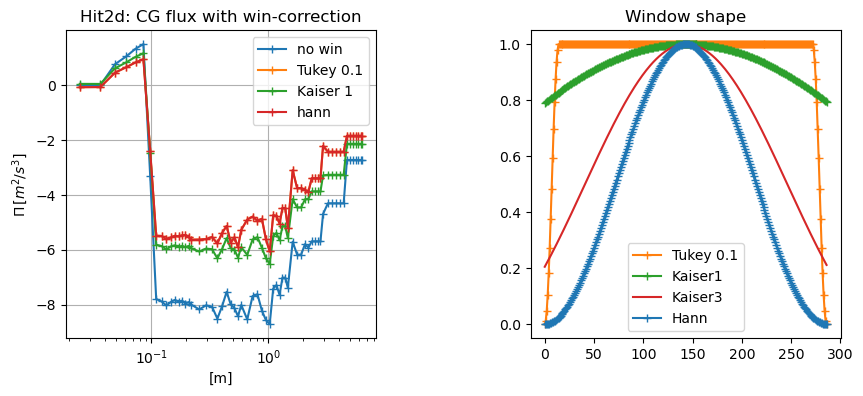

In [9]:
from matplotlib.gridspec import GridSpec
#'#ff7f0e','#2ca02c','#d62728'
fig2 = plt.figure(figsize=(10, 4))
gs = GridSpec(1, 2, figure=fig2, height_ratios=[1], wspace=0.5)
ax2 = [
    [fig2.add_subplot(gs[0, 0]), fig2.add_subplot(gs[0, 1])]  # First row (3 columns)
]

ax2[0][0].semilogx(filtscale,Thm,marker='+',linewidth=1.5,label='no win')
ax2[0][0].semilogx(filtscale,Thm_tukey,marker='+',linewidth=1.5,label='Tukey 0.1')
ax2[0][0].semilogx(filtscale,Thm_kaiser,marker='+',linewidth=1.5,label='Kaiser 1')
ax2[0][0].semilogx(filtscale,Thm_hann,marker='+',linewidth=1.5,label='hann')

ax2[0][0].legend()
ax2[0][0].grid(True)
ax2[0][0].set_xlabel('[m]')
ax2[0][0].set_ylabel('$\Pi \, [m^{2}/s^{3}]$')
ax2[0][0].set_title('Hit2d: CG flux with win-correction')

from skimage.filters import window
from scipy.signal import get_window
Nx=287
Tukey01=window(('tukey', 0.1), Nx)
Kaiser1 = get_window(('kaiser', 1), Nx)
Kaiser3 = get_window(('kaiser', 3), Nx)
hann=window('hann',Nx)
ax2[0][1].plot(np.arange(Nx),Tukey01,marker='+',linewidth=1.5,label='Tukey 0.1',color='#ff7f0e')
ax2[0][1].plot(np.arange(Nx),Kaiser1,marker='+',linewidth=1.5,label='Kaiser1',color='#2ca02c')
ax2[0][1].plot(np.arange(Nx),Kaiser3,linewidth=1.5,label='Kaiser3',color='#d62728')
ax2[0][1].plot(np.arange(Nx),hann,marker='+',linewidth=1.5,label='Hann',color='#1f77b4')
ax2[0][1].legend()
ax2[0][1].set_title('Window shape')

plt.show()

In [4]:
Nx=287
beta=3
window_x = get_window(('kaiser', beta), Nx)
window_y = get_window(('kaiser', beta), Nx)
# window_x = get_window(('tukey', 0.1), Nx)
# window_y = get_window(('tukey', 0.1), Nx)
# window_x = window('hann', Nx)
# window_y = window('hann', Nx)
w = np.outer(window_y, window_x)
w.size

window_energy = np.sum(w**2)
correction_factor = np.sqrt(w.size / window_energy)
correction_factor

1.8795523693163576

In [5]:
8/3

2.6666666666666665

In [5]:
# hf
data_dir='/meddy/simingzhang/Data/RB_iceland_data/'
fname='s2sflux_spec_hf_hann.0002.nc'
# fname='s2sflux_spec_smooth_uni.0002.nc'
cgfile=data_dir+fname
print(cgfile)
ds=xr.open_dataset(cgfile)
Thm_hann_hf=ds['Thm'].values[1:]
filtscale=ds['filtscale'].values[1:]

fname='s2sflux_spec_hf_hann_corr.0002.nc'
# fname='s2sflux_spec_smooth_uni.0002.nc'
cgfile=data_dir+fname
print(cgfile)
ds=xr.open_dataset(cgfile)
Thm_hann_corr_hf=ds['Thm'].values[1:]
filtscale=ds['filtscale'].values[1:]

fname='s2sflux_spec_hf_tukey.0002.nc'
# fname='s2sflux_spec_smooth_uni.0002.nc'
cgfile=data_dir+fname
print(cgfile)
ds=xr.open_dataset(cgfile)
Thm_tukey_hf=ds['Thm'].values[1:]
filtscale=ds['filtscale'].values[1:]

fname='s2sflux_spec_hf_kaiser_corr.0002.nc'
# fname='s2sflux_spec_smooth_uni.0002.nc'
cgfile=data_dir+fname
print(cgfile)
ds=xr.open_dataset(cgfile)
Thm_kaiser_corr_hf=ds['Thm'].values[1:]
filtscale=ds['filtscale'].values[1:]

fname='s2sflux_spec_hf_kaiser3_corr.0002.nc'
# fname='s2sflux_spec_smooth_uni.0002.nc'
cgfile=data_dir+fname
print(cgfile)
ds=xr.open_dataset(cgfile)
Thm_kaiser3_corr_hf=ds['Thm'].values[1:]
filtscale=ds['filtscale'].values[1:]

# smooth
fname='s2sflux_spec_smooth_hann_corr.0002.nc'
# fname='s2sflux_spec_smooth_uni.0002.nc'
cgfile=data_dir+fname
print(cgfile)
ds=xr.open_dataset(cgfile)
Thm_hann_corr_sm=ds['Thm'].values[1:]
filtscale=ds['filtscale'].values[1:]

fname='s2sflux_spec_smooth_tukey.0002.nc'
# fname='s2sflux_spec_smooth_uni.0002.nc'
cgfile=data_dir+fname
print(cgfile)
ds=xr.open_dataset(cgfile)
Thm_tukey_sm=ds['Thm'].values[1:]
filtscale=ds['filtscale'].values[1:]

fname='s2sflux_spec_smooth_kaiser_corr.0002.nc'
# fname='s2sflux_spec_smooth_uni.0002.nc'
cgfile=data_dir+fname
print(cgfile)
ds=xr.open_dataset(cgfile)
Thm_kaiser_corr_sm=ds['Thm'].values[1:]
filtscale=ds['filtscale'].values[1:]

fname='s2sflux_spec_smooth_kaiser3_corr.0002.nc'
# fname='s2sflux_spec_smooth_uni.0002.nc'
cgfile=data_dir+fname
print(cgfile)
ds=xr.open_dataset(cgfile)
Thm_kaiser3_corr_sm=ds['Thm'].values[1:]
filtscale=ds['filtscale'].values[1:]

fname='s2sflux_spec_smooth_hann.0002.nc'
# fname='s2sflux_spec_smooth_uni.0002.nc'
cgfile=data_dir+fname
print(cgfile)
ds=xr.open_dataset(cgfile)
Thm_hann_sm=ds['Thm'].values[1:]
filtscale=ds['filtscale'].values[1:]


# 2d field
gridname='/meddy/simingzhang/Data/RB_iceland_data/niskin2km_500m_grd.nc'
grid=xr.open_dataset(gridname)
lonr=grid['lon_rho'].values
latr=grid['lat_rho'].values


fname='s2sflux_spec_all_hf_hann_corr.0002.nc'
cgfile=data_dir+fname
ds=xr.open_dataset(cgfile)
tin=100
Th2_hann_corr_hf=np.squeeze(ds['Th2'].values[tin,:,:,:])

fname='s2sflux_spec_all_smooth_hann_corr.0002.nc'
cgfile=data_dir+fname
ds=xr.open_dataset(cgfile)
tin=100
Th2_hann_corr_sm=np.squeeze(ds['Th2'].values[tin,:,:,:])

/meddy/simingzhang/Data/RB_iceland_data/s2sflux_spec_hf_hann.0002.nc
/meddy/simingzhang/Data/RB_iceland_data/s2sflux_spec_hf_hann_corr.0002.nc
/meddy/simingzhang/Data/RB_iceland_data/s2sflux_spec_hf_tukey.0002.nc
/meddy/simingzhang/Data/RB_iceland_data/s2sflux_spec_hf_kaiser_corr.0002.nc
/meddy/simingzhang/Data/RB_iceland_data/s2sflux_spec_hf_kaiser3_corr.0002.nc
/meddy/simingzhang/Data/RB_iceland_data/s2sflux_spec_smooth_hann_corr.0002.nc
/meddy/simingzhang/Data/RB_iceland_data/s2sflux_spec_smooth_tukey.0002.nc
/meddy/simingzhang/Data/RB_iceland_data/s2sflux_spec_smooth_kaiser_corr.0002.nc
/meddy/simingzhang/Data/RB_iceland_data/s2sflux_spec_smooth_kaiser3_corr.0002.nc
/meddy/simingzhang/Data/RB_iceland_data/s2sflux_spec_smooth_hann.0002.nc


<>:25: SyntaxWarning: invalid escape sequence '\P'
<>:39: SyntaxWarning: invalid escape sequence '\P'
<>:25: SyntaxWarning: invalid escape sequence '\P'
<>:39: SyntaxWarning: invalid escape sequence '\P'
/tmp/ipykernel_3801034/2650600728.py:25: SyntaxWarning: invalid escape sequence '\P'
  ax2[0][0].set_ylabel('$\Pi \, [m^{2}/s^{3}]$')
/tmp/ipykernel_3801034/2650600728.py:39: SyntaxWarning: invalid escape sequence '\P'
  ax2[0][1].set_ylabel('$\Pi \, [m^{2}/s^{3}]$')


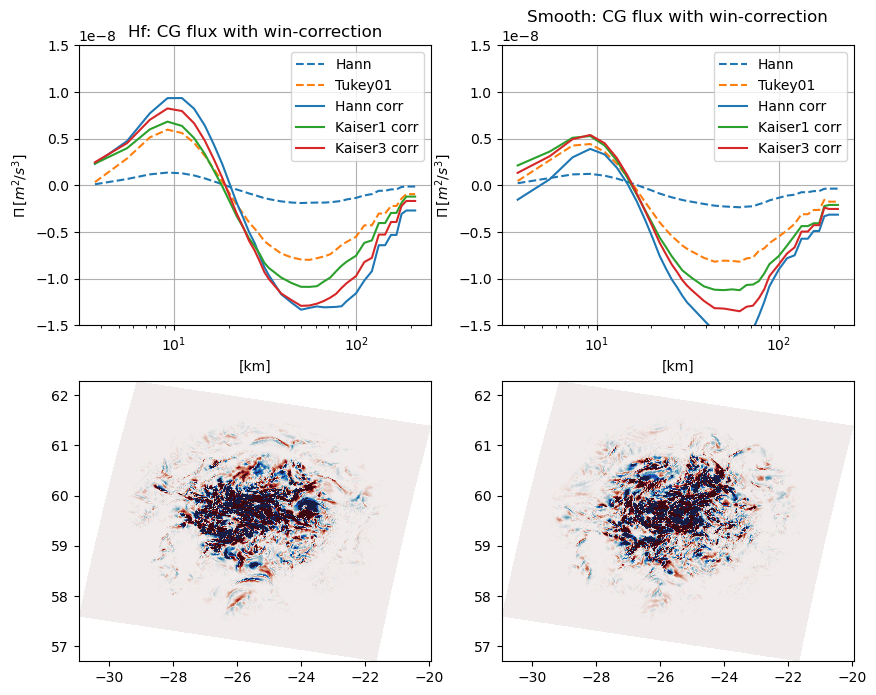

In [6]:
from matplotlib.gridspec import GridSpec
colors={'#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf'}
from cmocean import cm

fig2 = plt.figure(figsize=(10, 8))
gs = GridSpec(2, 2, figure=fig2)
ax2 = [
    [fig2.add_subplot(gs[0, 0]), fig2.add_subplot(gs[0, 1])],  # First row (3 columns)
    [fig2.add_subplot(gs[1, 0]), fig2.add_subplot(gs[1, 1])]
]

# ax2[0][0].semilogx(filtscale,Thm,marker='+',linewidth=1.5,label='no win')
ax2[0][0].semilogx(filtscale/1e3,Thm_hann_hf,linewidth=1.5,label='Hann',linestyle='--')
ax2[0][0].semilogx(filtscale/1e3,Thm_tukey_hf,linewidth=1.5,label='Tukey01',linestyle='--')
ax2[0][0].semilogx(filtscale/1e3,Thm_hann_corr_hf,color='#1f77b4',linewidth=1.5,label='Hann corr')
ax2[0][0].semilogx(filtscale/1e3,Thm_kaiser_corr_hf,linewidth=1.5,label='Kaiser1 corr')
ax2[0][0].semilogx(filtscale/1e3,Thm_kaiser3_corr_hf,linewidth=1.5,label='Kaiser3 corr')


# ax2[0][0].semilogx(filtscale,Thm_hann,marker='+',linewidth=1.5,label='hann')

ax2[0][0].legend()
ax2[0][0].grid(True)
ax2[0][0].set_xlabel('[km]')
ax2[0][0].set_ylabel('$\Pi \, [m^{2}/s^{3}]$')
ax2[0][0].set_title('Hf: CG flux with win-correction')
ax2[0][0].set_ylim([-1.5e-8,1.5e-8])

ax2[0][1].semilogx(filtscale/1e3,Thm_hann_sm,linewidth=1.5,label='Hann',linestyle='--')
ax2[0][1].semilogx(filtscale/1e3,Thm_tukey_sm,linewidth=1.5,label='Tukey01',linestyle='--')
ax2[0][1].semilogx(filtscale/1e3,Thm_hann_corr_sm,color='#1f77b4',linewidth=1.5,label='Hann corr')
ax2[0][1].semilogx(filtscale/1e3,Thm_kaiser_corr_sm,linewidth=1.5,label='Kaiser1 corr')
ax2[0][1].semilogx(filtscale/1e3,Thm_kaiser3_corr_sm,linewidth=1.5,label='Kaiser3 corr')


ax2[0][1].legend()
ax2[0][1].grid(True)
ax2[0][1].set_xlabel('[km]')
ax2[0][1].set_ylabel('$\Pi \, [m^{2}/s^{3}]$')
ax2[0][1].set_title('Smooth: CG flux with win-correction')
ax2[0][1].set_ylim([-1.5e-8,1.5e-8])

ax2[1][0].pcolormesh(lonr,latr,Th2_hann_corr_hf,cmap=cm.balance,vmin=-1e-6,vmax=1e-6)

ax2[1][1].pcolormesh(lonr,latr,Th2_hann_corr_sm,cmap=cm.balance,vmin=-1e-6,vmax=1e-6)


In [32]:
from skimage.filters import window
from scipy.signal import get_window
Nx=512

# window_x = window(('tukey',0.1), Nx)
# window_y = window(('tukey',0.1), Nx)
# window_x = get_window(('kaiser',1), Nx)
# window_y = get_window(('kaiser',1), Nx)
# window_x = get_window(('tukey',0.1), Nx)
# window_y = get_window(('tukey',0.1), Nx)
window_x = get_window('hann', Nx)
window_y = get_window('hann', Nx)
w = np.outer(window_y, window_x)
w.size

window_energy = np.sum(w**2)
correction_factor = np.sqrt(w.size / window_energy)
correction_factor

2.6666666666666665

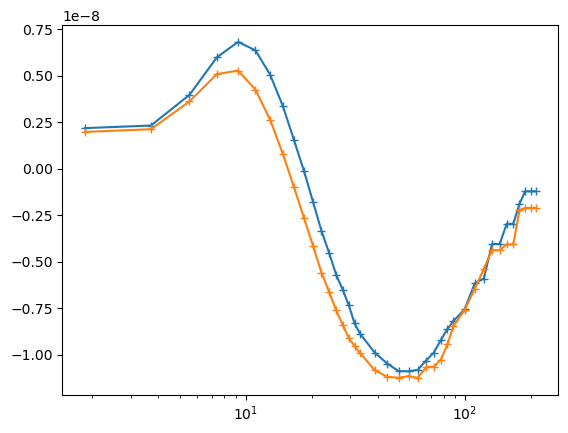

In [33]:
plt.semilogx(filtscale/1e3,Thm_kaiser_corr_hf,marker='+',linewidth=1.5,label='hf Kaiser1 corr')
plt.semilogx(filtscale/1e3,Thm_kaiser_corr_sm,marker='+',linewidth=1.5,label='sm Kaiser1 corr')


In [20]:
from scipy.fft import rfft2, irfft2
from skimage.filters import window
Nx=287
Ny=287
kx = np.fft.fftfreq(Nx, d=1./Nx)
ky = np.fft.fftfreq(Ny, d=1./Ny)
nk = Nx//2 + 1
KY, KX = np.meshgrid(ky[:nk], kx)

def sfilt(ur, r):
    w = window(('tukey', 0.1), ur.shape)
    u = rfft2(ur*w)
    nx, nk = u.shape
    nc = nx/2.0/r
    K2 = KX**2 + KY**2
    mask = K2>nc**2
    u[mask] = 0
    return irfft2(u)

v1=np.zeros((Nx,Ny))
v2=sfilt(v1,2)
v2.shape

In [22]:
v2=sfilt(v1,2)

In [23]:
v2.shape

(287, 286)

In [25]:
KX.shape,KY.shape

((287, 144), (287, 144))

In [88]:
from netCDF4 import Dataset

def ncopen(dr, filestr, depth, opt = 'r'):
    filen = dr + filestr+'.{0:04}'.format(depth)+'.nc'
    print('*******************************************')
    print(filen)
    return Dataset(filen, opt)
    
depth=2
dr='/meddy/simingzhang/Data/RB_iceland_data/'

In [89]:
nco = ncopen(dr, 's2sflux_spec_allwww', depth, 'w')

*******************************************
/meddy/simingzhang/Data/RB_iceland_data/s2sflux_spec_allwww.0002.nc


In [90]:
Nx=287
Ny=280
TT=2148
DD=1

In [91]:
# 1. 定义维度
nco.createDimension('time', TT)        # 无限制大小，时间维度
nco.createDimension('depth', DD)   # 深度维度
nco.createDimension('eta_rho', Ny)    # eta_rho 维度
nco.createDimension('xi_rho', Nx)     # xi_rho 维度

# times = nco.createVariable('time', 'f4', ('time',))
# depths = nco.createVariable('depth', 'f4', ('depth',))
# etas = nco.createVariable('eta_rho', 'f4', ('eta_rho',))
# xis = nco.createVariable('xi_rho', 'f4', ('xi_rho',))

varlist = ['Th', 'Ek']
for var in varlist:
    # 创建四维变量 (time, depth, eta_rho, xi_rho)
    nco.createVariable(var+'_4d', 'f4', ('time', 'depth', 'eta_rho', 'xi_rho'))

nco.variables['Th_4d'][:] = np.zeros((TT,DD,Ny,Nx))
nco.variables['Ek_4d'][:] = 3

In [92]:
nco.close()


In [40]:
nch = ncopen(dr, 'z_niskin2km_his_smooth_depth_500m_grd', depth)


*******************************************
/meddy/simingzhang/Data/RB_iceland_data/z_niskin2km_his_smooth_depth_500m_grd.0002.nc


In [42]:
def ncload(nc, var, itime = None, ij = None, func = None):
    
    if ij is not None:
        imin, imax, jmin, jmax = ij[0], ij[1], ij[2], ij[3]
    else:
        imin, imax, jmin, jmax = 0, None, 0, None
    
    xx = nc.variables[var].dimensions[-1]
    yy = nc.variables[var].dimensions[-2]
    
    if yy=='eta_v':
        if jmax is not None:
            jmax = jmax - 1
        #jmax = -1 if jmax is None else jmax = jmax - 1
    if xx=='xi_u':
        if imax is not None:
            imax = imax - 1
        #imax = -1 if imax is None else imax = imax - 1
    
    if itime is None:
        var1 = Forder(nc.variables[var][...,jmin:jmax,imin:imax]) 
    else:
        if isinstance(itime, list) or isinstance(itime, tuple):
            #print 'here'
            var1 = np.squeeze(Forder(nc.variables[var][itime[0]:itime[1],...,jmin:jmax,imin:imax])) 
            #print('inside time list before function', var1.shape)       
        else:
            var1 = Forder(nc.variables[var][itime,...,jmin:jmax,imin:imax]) 
    if func is None:
        return var1
    else:
        return func(var1)
    #return var1 if func is None else return func(var1)
import R_tools_new_goth as tN


In [53]:
u1=tN.ncload(nch, 'u',2148)

IndexError: index exceeds dimension bounds

In [52]:
u1.shape

(286, 287, 1)

In [54]:

for p in range(0,2148):
    print(p)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [55]:
Narray = list(range(1,18))
Narray.extend(list(range(18,int(48),int(3))))
Narray.extend(list(range(48,int(120),int(6))))
N0 = len(Narray)

In [56]:
Narray

[1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 21,
 24,
 27,
 30,
 33,
 36,
 39,
 42,
 45,
 48,
 54,
 60,
 66,
 72,
 78,
 84,
 90,
 96,
 102,
 108,
 114]

In [63]:
varlist2 = []  # 创建空列表
for xsc in range(N0):
    # 使用 append() 添加元素
    varlist2.append('Th'+str(Narray[xsc]))
    
print(varlist2)

['Th1', 'Th2', 'Th3', 'Th4', 'Th5', 'Th6', 'Th7', 'Th8', 'Th9', 'Th10', 'Th11', 'Th12', 'Th13', 'Th14', 'Th15', 'Th16', 'Th17', 'Th18', 'Th21', 'Th24', 'Th27', 'Th30', 'Th33', 'Th36', 'Th39', 'Th42', 'Th45', 'Th48', 'Th54', 'Th60', 'Th66', 'Th72', 'Th78', 'Th84', 'Th90', 'Th96', 'Th102', 'Th108', 'Th114']


In [61]:
str(Narray[xsc])

'1'

In [65]:
varlist2[0]

'Th1'

In [13]:
dsg=xr.open_dataset(f'{data_dir}niskin2km_500m_grd.nc')
dsd=xr.open_dataset(f'{data_dir}s2sflux_spec_all_smooth.0002.nc')

In [14]:
lon=dsg['lon_rho'].values
lat=dsg['lat_rho'].values

In [15]:
Th1=dsd['Th1'].values
Th10=dsd['Th10'].values

In [16]:
Th1.shape

(2148, 1, 287, 287)

Text(0.5, 1.0, 'Th10')

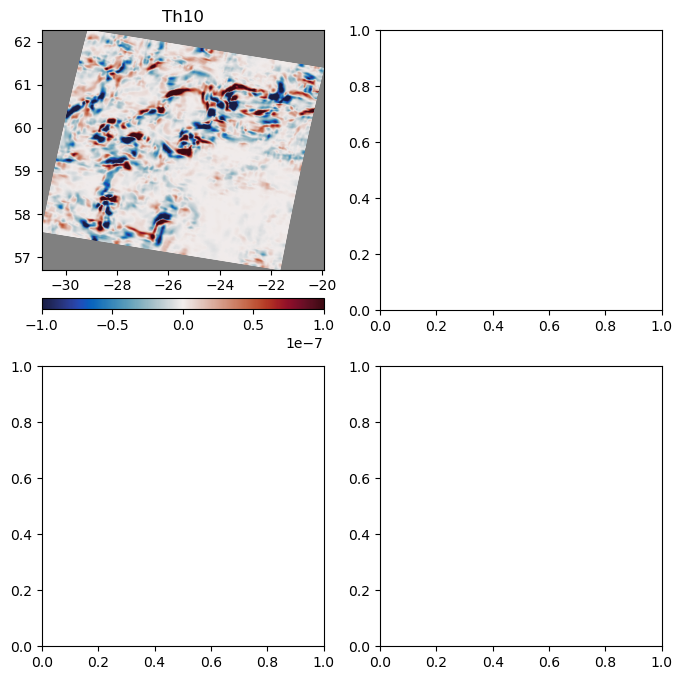

In [21]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.gridspec import GridSpec
from matplotlib.colors import SymLogNorm
from cmocean import cm
magn=1e-7


# 创建图形和网格布局
fig2 = plt.figure(figsize=(8, 8))
gs = GridSpec(2, 2, figure=fig2)  # 2行2列

# 左列子图使用 PlateCarree 投影
ax00 = fig2.add_subplot(gs[0, 0])
ax10 = fig2.add_subplot(gs[1, 0])

# 右列子图不使用投影
ax01 = fig2.add_subplot(gs[0, 1])
ax11 = fig2.add_subplot(gs[1, 1])

# 定义坐标轴对象数组
ax2 = [[ax00, ax01], [ax10, ax11]]

ax2[0][0].set_facecolor('grey')
cs2 = ax2[0][0].pcolormesh(lon, lat, Th10[0,0,:,:], shading='gouraud', cmap=cm.balance, vmin=-magn, vmax=magn)
colorbar1 = fig2.colorbar(cs2, ax=ax2[0][0], orientation='horizontal', pad=0.1, fraction=0.045, aspect=25)

ax2[0][0].set_title('Th10')
